Without Lag Features

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [2]:
# Load dataset
df = pd.read_csv("weather_15min_interpolated_load_domestic.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
0,2025-06-10 00:00:00,25.600,94.00,100.0,0.0,6.4,0.201075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.837,peak load,0.9726
1,2025-06-10 00:15:00,25.675,94.25,100.0,0.0,6.4,0.331693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6044
2,2025-06-10 00:30:00,25.750,94.50,100.0,0.0,6.4,0.168803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8165
3,2025-06-10 00:45:00,25.825,94.75,100.0,0.0,6.4,0.200331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9690
4,2025-06-10 01:00:00,25.900,95.00,100.0,0.0,6.4,0.218110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0550


In [3]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
2972,2025-07-10 23:00:00,27.50,88.00,99.00,0.0,13.60,0.324147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5679
2973,2025-07-10 23:15:00,27.45,88.25,98.75,0.0,14.15,0.333223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6118
2974,2025-07-10 23:30:00,27.40,88.50,98.50,0.0,14.70,0.337544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6327
2975,2025-07-10 23:45:00,27.35,88.75,98.25,0.0,15.25,0.300682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4544
2976,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2976 non-null   datetime64[ns]
 1   temperature_C         2976 non-null   float64       
 2   humidity_percent      2976 non-null   float64       
 3   cloud_cover_percent   2976 non-null   float64       
 4   solar_irradiance_Wm2  2976 non-null   float64       
 5   wind_speed_ms         2976 non-null   float64       
 6   load_normalize        2976 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [5]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

C:\Users\HP\AppData\Local\Temp\ipykernel_22972\2707783040.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="linear")


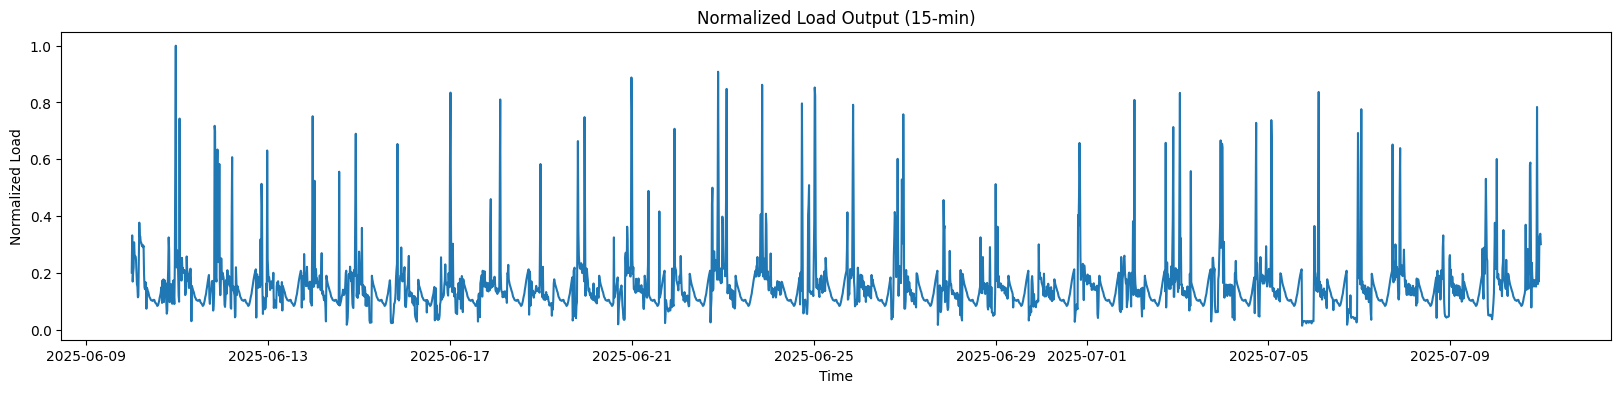

In [6]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["load_normalize"])
plt.title("Normalized Load Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.show()

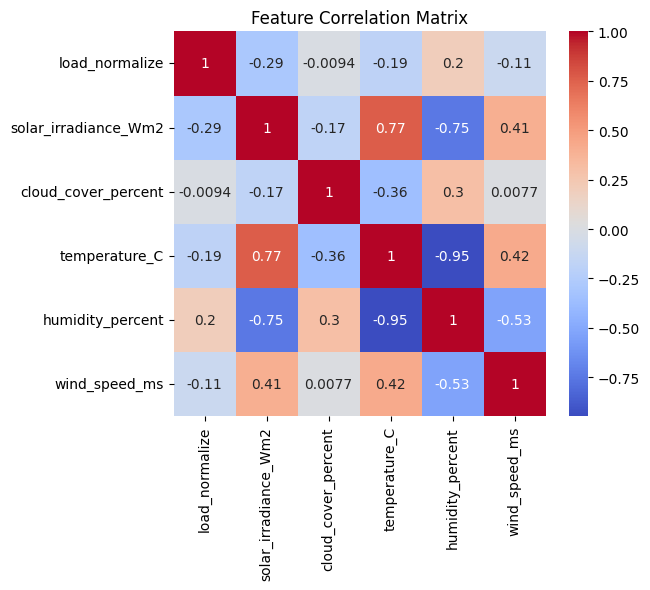

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "load_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
# Time-based features
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofyear"] = df["timestamp"].dt.dayofyear

# Solar power lags
# df["solar_lag_1"] = df["solar_normalize"].shift(1)
# df["solar_lag_2"] = df["solar_normalize"].shift(2)
# df["solar_lag_4"] = df["solar_normalize"].shift(4)

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [10]:
y = df[["load_normalize"]]
X = df[
    [
        "humidity_percent",
        "hour",
        "minute",
        "dayofyear"

    ]
]

In [11]:
len(X), len(y)

(2977, 2977)

In [12]:
X.head()

,humidity_percent,hour,minute,dayofyear
0,94.00,0,0,161
1,94.25,0,15,161
2,94.50,0,30,161
3,94.75,0,45,161
4,95.00,1,0,161


In [13]:
y.head()

,load_normalize
0,0.201075
1,0.331693
2,0.168803
3,0.200331
4,0.218110


In [14]:
# Total samples
total_samples = len(df)

# Samples per day (15-min data)
samples_per_day = 96

# Total number of days
total_days = total_samples // samples_per_day

print("Total days:", total_days)

# Split ratios
train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

print(train_days, val_days, test_days)

# Convert days → indices
train_end = train_days * samples_per_day
val_end   = train_end + (val_days * samples_per_day)

# Split data (IMPORTANT: no shuffling)
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

Total days: 31
21 4 6


In [15]:
from sklearn.model_selection import ParameterSampler
from lightgbm import early_stopping, log_evaluation

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "num_leaves": [20, 31, 50],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Randomly sample combinations
param_list = list(ParameterSampler(param_dist, n_iter=15, random_state=42))

best_rmse = float("inf")
best_model = None
best_params = None

for i, params in enumerate(param_list):
    print(f"Trial {i+1}/{len(param_list)}")

    model = LGBMRegressor(random_state=42, **params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
        early_stopping(stopping_rounds=20),log_evaluation(0)
        ],
    )

    y_val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print("RMSE:", rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_params = params


print("\nBest Parameters:", best_params)
print("Best Validation RMSE:", best_rmse)

y_test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test RMSE:", test_rmse)
print("Best Iteration:", best_model.best_iteration_)


Trial 1/15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 152
[LightGBM] [Info] Number of data points in the train set: 2016, number of used features: 4
[LightGBM] [Info] Start training from score 0.152695
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[27]	valid_0's rmse: 0.102862	valid_0's l2: 0.0105805
RMSE: 0.10286179336134575
Trial 2/15
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 152
[LightGBM] [Info] Number of data points in the train set: 2016, number of used features: 4
[LightGBM] [Info] Start training from score 0.152695
Training until validation scores don't improve for 20 rounds

In [16]:
y_test_np = np.array(y_test)
y_pred_np = np.array(y_test_pred)

# MAE
test_mae = mean_absolute_error(y_test_np, y_pred_np)

# R2 Score
test_r2 = r2_score(y_test_np, y_pred_np)

# RMSE
test_rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))

print("\nTest MAE:", test_mae)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)



Test MAE: 0.054475124089757465
Test R2: -0.008460902117210178
Test RMSE: 0.1035844988197774


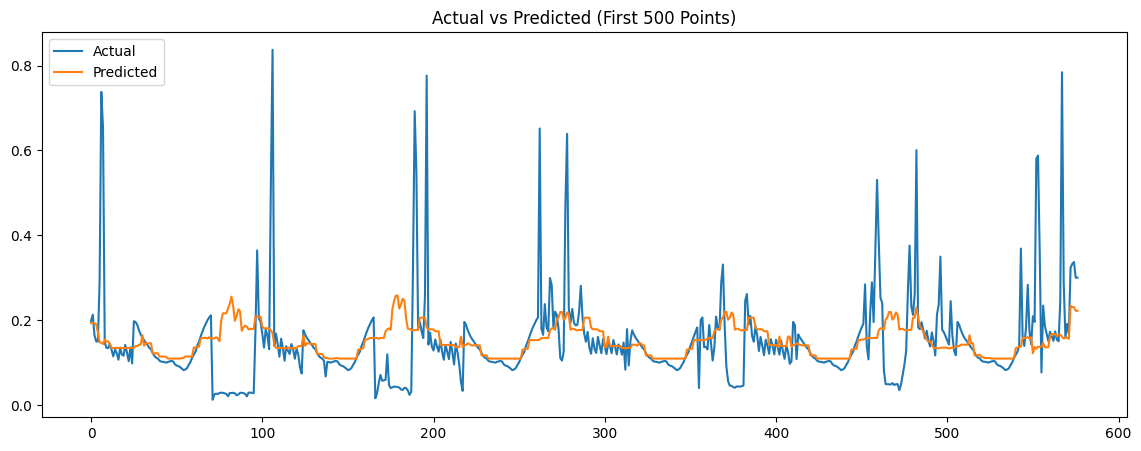

In [18]:
n = 500  # change as needed

plt.figure(figsize=(14,5))

plt.plot(y_test_np[0:1000], label="Actual")
plt.plot(y_pred_np[0:1000], label="Predicted")

plt.title(f"Actual vs Predicted (First {n} Points)")
plt.legend()

plt.show()